In [1]:
# step-0:installation & set-up
!pip install kaggle -q
import os, random, re, shutil
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.19.0


In [2]:
# step-1: BUSI dataset download from kaggle
from google.colab import files
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset
!unzip -q breast-ultrasound-images-dataset.zip -d /content/BUSI
print('Dataset ready!')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
 68% 132M/195M [00:00<00:00, 1.38GB/s]
100% 195M/195M [00:00<00:00, 741MB/s] 
Dataset ready!


In [3]:
import os
def find_busi_path(base='/content/BUSI'):
    for root, dirs, files in os.walk(base):
        if 'benign' in dirs and 'malignant' in dirs and 'normal' in dirs:
            print(f'found BUSI dataset at: {root}')
            return root
    raise FileNotFoundError('could not find BUSI dataset folder, pls check the unzip path.')

DATASET_PATH = find_busi_path()
print(f'DATASET_PATH set to: {DATASET_PATH}')

for cls in ['benign','malignant','normal']:
    n = len([f for f in os.listdir(os.path.join(DATASET_PATH, cls)) if '_mask' not in f and f.endswith('.png')])
    print(f'  {cls}: {n} images (masks excluded)')

found BUSI dataset at: /content/BUSI/Dataset_BUSI_with_GT
DATASET_PATH set to: /content/BUSI/Dataset_BUSI_with_GT
  benign: 437 images (masks excluded)
  malignant: 210 images (masks excluded)
  normal: 133 images (masks excluded)


In [4]:
# step-2:configuration
DATASET_PATH = '/content/BUSI/Dataset_BUSI_with_GT'
OUTPUT_DIR   = '/content/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE   = 224
BATCH_SIZE = 32
CLASSES    = ['benign', 'malignant', 'normal']
CLASS_NAMES = ['Benign', 'Malignant', 'Normal']
NUM_CLASSES = 3

# Training hyperparameters
LR_PHASE1  = 1e-3
LR_PHASE2  = 1e-5
EPOCHS_P1  = 10
EPOCHS_P2  = 10
TOTAL_EPOCHS = EPOCHS_P1 + EPOCHS_P2

print(f'configuration loaded. Dataset: {DATASET_PATH}')

configuration loaded. Dataset: /content/BUSI/Dataset_BUSI_with_GT


In [5]:
# step-3: loading of BUSI datset & implementation of patient hold-out split
def load_busi_records(root_dir):
    records = []
    for label in CLASSES:
        folder = os.path.join(root_dir, label)
        if not os.path.isdir(folder):
            print(f'warning: {folder} not found'); continue
        for fname in sorted(os.listdir(folder)):
            if '_mask' in fname or not fname.endswith('.png'):
                continue
            match = re.search(r'\((\d+)\)', fname)
            pid = f"{label}_{match.group(1)}" if match else f"{label}_{fname}"
            records.append({'patient_id': pid, 'label': label,
                            'filepath': os.path.join(folder, fname)})
    print(f'loaded {len(records)} images (masks excluded)')
    return records



# patient hold-out strategy
def patient_holdout_split(records, train_ratio=0.70, val_ratio=0.15, seed=42):
    rng = random.Random(seed)
    by_patient = defaultdict(list)
    for r in records:
        by_patient[r['patient_id']].append(r)

    # stratification by majority label per patient
    by_label = defaultdict(list)
    for pid, recs in by_patient.items():
        labels = [r['label'] for r in recs]
        majority = max(set(labels), key=labels.count)
        by_label[majority].append(pid)

    train_pids, val_pids, test_pids = [], [], []
    for label, pids in by_label.items():
        rng.shuffle(pids)
        n = len(pids)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)
        train_pids += pids[:n_train]
        val_pids   += pids[n_train:n_train+n_val]
        test_pids  += pids[n_train+n_val:]

    # verifying zero overlap
    assert len(set(train_pids) & set(val_pids))  == 0, 'OVERLAP: train/val!'
    assert len(set(train_pids) & set(test_pids)) == 0, 'OVERLAP: train/test!'
    assert len(set(val_pids)   & set(test_pids)) == 0, 'OVERLAP: val/test!'

    def collect(pids):
        result = []
        for pid in pids:
            result.extend(by_patient[pid])
        return result

    train_recs = collect(train_pids)
    val_recs   = collect(val_pids)
    test_recs  = collect(test_pids)

    info = {
        'total_images':   len(records),
        'total_patients': len(by_patient),
        'train_images':   len(train_recs), 'train_patients': len(train_pids),
        'val_images':     len(val_recs),   'val_patients':   len(val_pids),
        'test_images':    len(test_recs),  'test_patients':  len(test_pids),
    }
    return train_recs, val_recs, test_recs, info


# Load and split
records = load_busi_records(DATASET_PATH)
train_recs, val_recs, test_recs, split_info = patient_holdout_split(records)

print('\n Patient Hold-Out Split Results: ')
print(f"Total : {split_info['total_images']} images / {split_info['total_patients']} patients")
print(f"Train : {split_info['train_images']} images / {split_info['train_patients']} patients")
print(f"Val   : {split_info['val_images']} images / {split_info['val_patients']} patients")
print(f"Test  : {split_info['test_images']} images / {split_info['test_patients']} patients")
print('Patient overlap: 0 (verified ✓)')

loaded 780 images (masks excluded)

 Patient Hold-Out Split Results: 
Total : 780 images / 780 patients
Train : 545 images / 545 patients
Val   : 115 images / 115 patients
Test  : 120 images / 120 patients
Patient overlap: 0 (verified ✓)


In [6]:
# step-4: preprocessing & data augmentation(for training datset only)
def preprocess_image(filepath, augment=False):

    # load grayscale
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    # CLAHE enhancement-for enhancing local contrast in low-echo tumor regions
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img   = clahe.apply(img)

    # gaussian denoising-for reducing ultrasound speckle noise
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # grayscale to 3-channel RGB(since ResNet50 expects 3 channels)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    # resizing to 224x224 (which is ResNet50 i/p requirement)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    img = img.astype(np.float32)



    # augmentation
    if augment:
        # horizontal flip (p=0.5); to probe symmetry
        if random.random() > 0.5:
            img = img[:, ::-1, :]

        # vertical flip(p=0.5); to probe symmetry
        if random.random() > 0.5:
            img = img[::-1, :, :]

        # rotation +-25 degrees; to probe angle variation
        angle = random.uniform(-25, 25)
        M = cv2.getRotationMatrix2D((IMG_SIZE//2, IMG_SIZE//2), angle, 1.0)
        img = cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE), borderMode=cv2.BORDER_REFLECT)

        # zoom 10%; to figure out the scale variation between scanners
        if random.random() > 0.5:
            scale = random.uniform(0.8, 1.2)
            M2 = cv2.getRotationMatrix2D((IMG_SIZE//2, IMG_SIZE//2), 0, scale)
            img = cv2.warpAffine(img, M2, (IMG_SIZE, IMG_SIZE), borderMode=cv2.BORDER_REFLECT)

        # brightness +-20%; to gain variation between machines
        if random.random() > 0.5:
            factor = random.uniform(0.8, 1.2)
            img = np.clip(img * factor, 0, 255)

        # gaussian noise; ultrasound speckle simulation
        if random.random() > 0.5:
            noise = np.random.normal(0, 12, img.shape).astype(np.float32)
            img = np.clip(img + noise, 0, 255)

    # ImageNet normalization
    img = preprocess_input(img)
    return img.astype(np.float32)


class BUSIDataGenerator(keras.utils.Sequence):
    def __init__(self, records, batch_size=32, augment=False, shuffle=True):
        self.records    = records
        self.batch_size = batch_size
        self.augment    = augment
        self.shuffle    = shuffle
        self.label_map  = {c: i for i, c in enumerate(CLASSES)}
        self.indices    = np.arange(len(records))
        if shuffle: np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.records) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        X = np.zeros((len(batch_idx), IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
        y = np.zeros((len(batch_idx), NUM_CLASSES), dtype=np.float32)
        for i, bi in enumerate(batch_idx):
            rec = self.records[bi]
            X[i] = preprocess_image(rec['filepath'], augment=self.augment)
            y[i, self.label_map[rec['label']]] = 1.0
        return X, y

    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.indices)


train_gen = BUSIDataGenerator(train_recs, BATCH_SIZE, augment=True,  shuffle=True)
val_gen   = BUSIDataGenerator(val_recs,   BATCH_SIZE, augment=False, shuffle=False)
test_gen  = BUSIDataGenerator(test_recs,  BATCH_SIZE, augment=False, shuffle=False)

print(f'Train batches: {len(train_gen)} | Val batches: {len(val_gen)} | Test batches: {len(test_gen)}')

Train batches: 18 | Val batches: 4 | Test batches: 4


In [7]:
# step-5: building of ResNet50 model
def build_resnet50_model(num_classes=3, input_shape=(224,224,3)):
    inputs = keras.Input(shape=input_shape)

    # ResNet50 backbone; ResNet50 pretrained on ImageNet (initially FROZEN)
    backbone = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)
    backbone.trainable = False  # Freezing initially

    # custom classification head
    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)   # 2048-d vector
    x = layers.Dense(512, kernel_regularizer=l2(0.001))(x)                #FC(512) + BatchNorm + ReLU + Dropout(0.5)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, kernel_regularizer=l2(0.001))(x)              #FC(128) + BatchNorm + ReLU + Dropout(0.3)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x) #FC(3)+Softmax
    model = Model(inputs=backbone.input, outputs=outputs)
    return model, backbone


model, backbone = build_resnet50_model()
model.summary()
print(f'\nTotal params:     {model.count_params():,}')
print(f'Trainable params: {sum([tf.size(v).numpy() for v in model.trainable_variables]):,}')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,705,411 (94.24 MB)

 Trainable params: 1,116,419 (4.26 MB)

 Non-trainable params: 23,588,992 (89.98 MB)


Total params:     24,705,411
Trainable params: 1,116,419


In [8]:
# step-6: phase-1 training (backbone frozen)

# computing class weights to handle class imbalance
from sklearn.utils.class_weight import compute_class_weight
train_labels = [r['label'] for r in train_recs]
label_indices = [CLASSES.index(l) for l in train_labels]
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=label_indices
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print('class weights:', class_weight_dict)

# PHASE 1: head only, backbone frozen
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7),
    ModelCheckpoint(f'{OUTPUT_DIR}/best_model_phase1.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('phase 1: training head only (backbone frozen)')
history_p1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_P1,
    callbacks=callbacks_p1,
    class_weight=class_weight_dict,
    verbose=1
)
print(f'phase 1 done. Best val_accuracy: {max(history_p1.history["val_accuracy"]):.4f}')


class weights: {0: np.float64(0.5956284153005464), 1: np.float64(1.2358276643990929), 2: np.float64(1.9534050179211468)}
phase 1: training head only (backbone frozen)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4959 - loss: 2.3530
Epoch 1: val_accuracy improved from None to 0.63478, saving model to /content/outputs/best_model_phase1.keras

Epoch 1: finished saving model to /content/outputs/best_model_phase1.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 161s 9s/step - accuracy: 0.5560 - loss: 2.1238 - val_accuracy: 0.6348 - val_loss: 2.1795 - learning_rate: 0.0010
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5911 - loss: 1.9603
Epoch 2: val_accuracy improved from 0.63478 to 0.68696, saving model to /content/outputs/best_model_phase1.keras

Epoch 2: finished saving model to /content/outputs/best_model_phase1.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 195s 8s/step - accuracy: 0.5945 - loss: 1.9040 - val_accuracy: 0.6870 - val_loss: 1.9614 - learning_rate: 0.0010
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6235 - loss: 1.7851
Epoch 3: val_accuracy did not improve from 0.68696
18/18 ━━━━━━━━━━━━━━━━━━━━ 139s 8s/step - acc

In [9]:
# step-7: phase 2 fine-tuning

# PHASE 2: unfreezing conv5_block (the actual last ResNet block)
backbone.trainable = True

for layer in backbone.layers:
    if 'conv5_block' in layer.name:
        layer.trainable = True   # unfreezing last ResNet block
    else:
        layer.trainable = False  # keeping all ,earlier layers frozen

trainable_count = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f'Phase 2 trainable params: {trainable_count:,}')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-8),
    ModelCheckpoint(f'{OUTPUT_DIR}/best_model_final.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('phase 2: fine-tuning conv5_block + head')
history_p2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_P2,
    callbacks=callbacks_p2,
    class_weight=class_weight_dict,
    verbose=1
)

Phase 2 trainable params: 16,092,419
phase 2: fine-tuning conv5_block + head
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6292 - loss: 1.4861 
Epoch 1: val_accuracy improved from None to 0.75652, saving model to /content/outputs/best_model_final.keras

Epoch 1: finished saving model to /content/outputs/best_model_final.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 220s 12s/step - accuracy: 0.6734 - loss: 1.5145 - val_accuracy: 0.7565 - val_loss: 1.3727 - learning_rate: 1.0000e-05
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.6589 - loss: 1.7190
Epoch 2: val_accuracy did not improve from 0.75652
18/18 ━━━━━━━━━━━━━━━━━━━━ 194s 11s/step - accuracy: 0.6881 - loss: 1.5272 - val_accuracy: 0.7391 - val_loss: 1.4166 - learning_rate: 1.0000e-05
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6959 - loss: 1.4017
Epoch 3: val_accuracy did not improve from 0.75652
18/18 ━━━━━━━━━━━━━━━━━━━━ 202s 11s/step - accuracy: 0.7064 - loss: 1.4101 - val_accuracy: 0.73

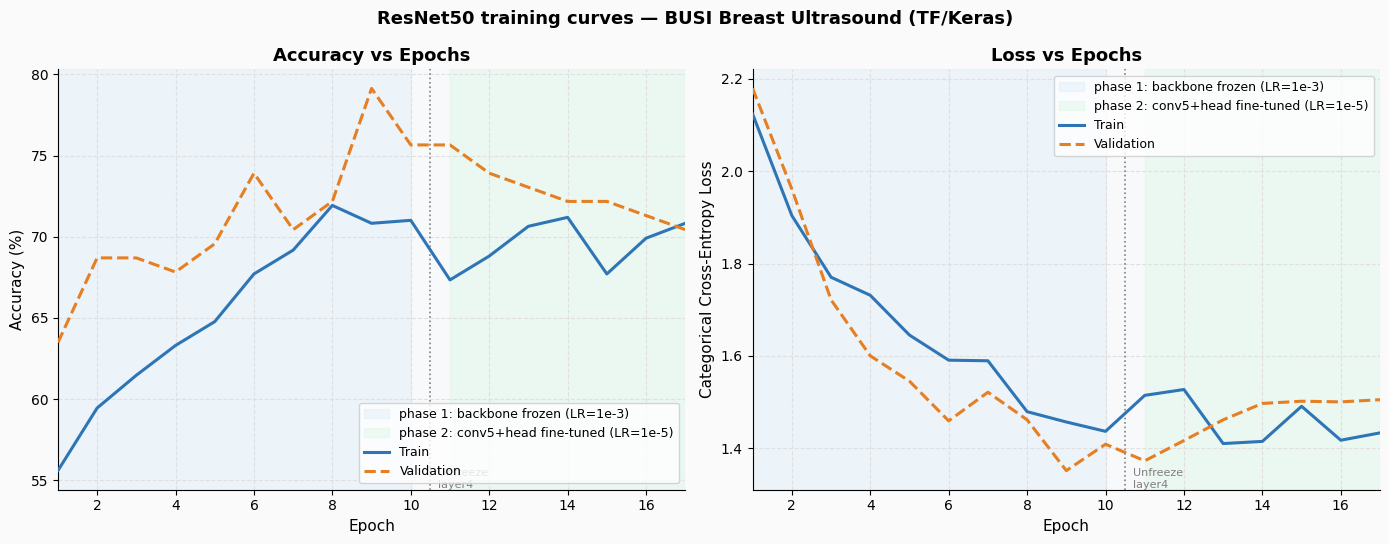

training curves saved.


In [11]:
# step-8: combining histories & plotting the training curves

# merging histories
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

history = merge_histories(history_p1, history_p2)
epochs_run = len(history['accuracy'])
ep = np.arange(1, epochs_run+1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#FAFAFA')
ph_colors = ['#D6EAF8', '#D5F5E3']
ph_labels = ['phase 1: backbone frozen (LR=1e-3)', 'phase 2: conv5+head fine-tuned (LR=1e-5)']

for ax, (ytr, yv, title, ylabel) in zip(axes, [
    (np.array(history['accuracy'])*100,     np.array(history['val_accuracy'])*100,
     'Accuracy vs Epochs', 'Accuracy (%)'),
    (history['loss'], history['val_loss'],
     'Loss vs Epochs', 'Categorical Cross-Entropy Loss'),
]):
    ax.set_facecolor('#F8F9FA')
    ax.grid(True, color='#E0E0E0', linewidth=0.8, linestyle='--')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    p1_end = len(history_p1.history['accuracy'])
    ax.axvspan(1, p1_end, alpha=0.35, color=ph_colors[0], label=ph_labels[0])
    ax.axvspan(p1_end+1, epochs_run, alpha=0.35, color=ph_colors[1], label=ph_labels[1])
    ax.plot(ep, ytr, color='#2E75B6', lw=2.2, label='Train', zorder=4)
    ax.plot(ep, yv,  color='#E67E22', lw=2.2, label='Validation', linestyle='--', zorder=4)
    ax.axvline(p1_end+0.5, color='gray', lw=1.2, linestyle=':', zorder=3)
    ax.text(p1_end+0.7, ax.get_ylim()[0], 'Unfreeze\nlayer4', fontsize=8, color='gray', va='bottom')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlim(1, epochs_run)
    handles, labels2 = ax.get_legend_handles_labels()
    ax.legend(handles, labels2, fontsize=9,
          loc='lower right' if 'Acc' in title else 'upper right')


plt.suptitle('ResNet50 training curves — BUSI Breast Ultrasound (TF/Keras)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('training curves saved.')

In [12]:
# step-9: evaluation on test dataset

# loading best model
best_model = keras.models.load_model(f'{OUTPUT_DIR}/best_model_final.keras')

# batch prediction
# building test arrays in one pass
y_true = np.array([{c: i for i, c in enumerate(CLASSES)}[r['label']] for r in test_recs])

# preprocessing all test images
X_test = np.zeros((len(test_recs), IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
for i, rec in enumerate(test_recs):
    X_test[i] = preprocess_image(rec['filepath'], augment=False)

# predicting in one batch call
y_pred_prob = best_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

print('\n Test set evaluation')
print(f'test images: {len(y_true)}')
print(f'overall accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%')
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))


4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 7s/step

 Test set evaluation
test images: 120
overall accuracy: 75.83%

              precision    recall  f1-score   support

      Benign     0.8548    0.7910    0.8217        67
   Malignant     0.5946    0.6875    0.6377        32
      Normal     0.7619    0.7619    0.7619        21

    accuracy                         0.7583       120
   macro avg     0.7371    0.7468    0.7404       120
weighted avg     0.7692    0.7583    0.7622       120



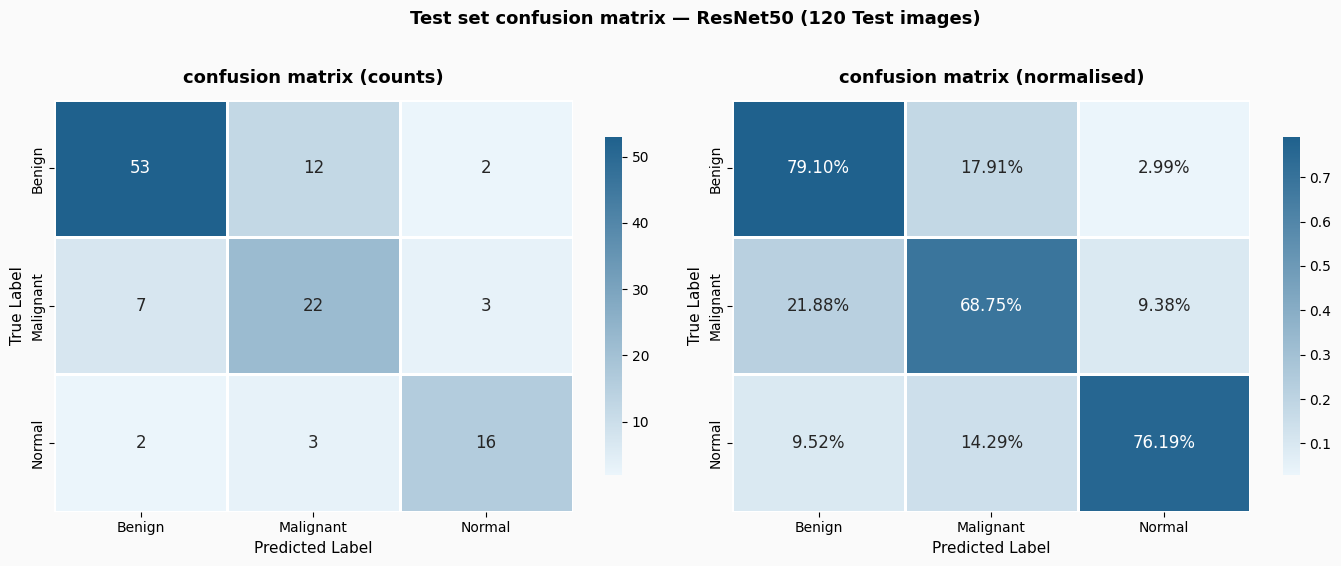

In [13]:
# step-10: confusion matrix
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cmap    = LinearSegmentedColormap.from_list('busi', ['#EBF5FB', '#1F618D'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#FAFAFA')
for ax, data, fmt, title in zip(axes, [cm, cm_norm], ['d', '.2%'],
    ['confusion matrix (counts)', 'confusion matrix (normalised)']):
    ax.set_facecolor('#FAFAFA')
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.8, linecolor='white',
                cbar_kws={'shrink': 0.82}, ax=ax, annot_kws={'size': 12})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.suptitle(f'Test set confusion matrix — ResNet50 ({len(y_true)} Test images)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

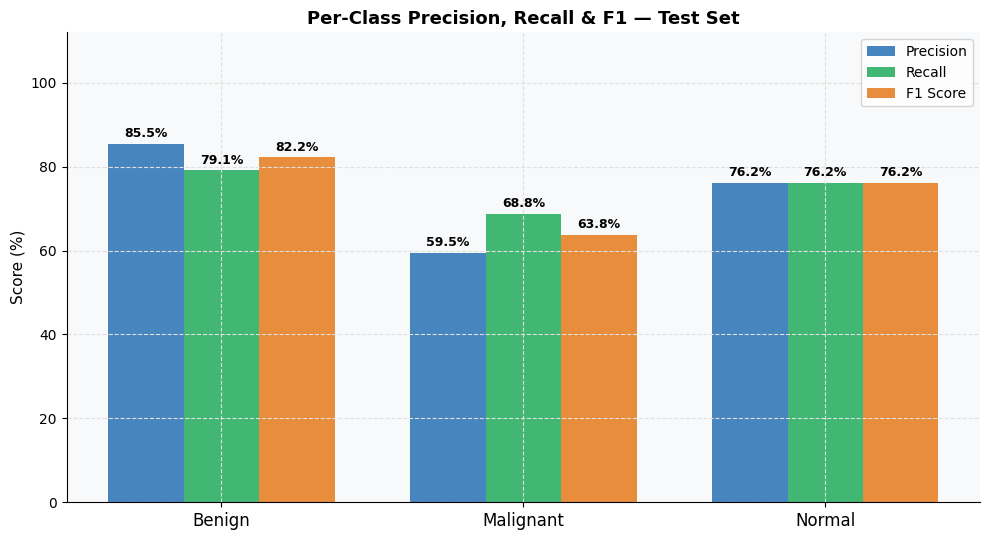

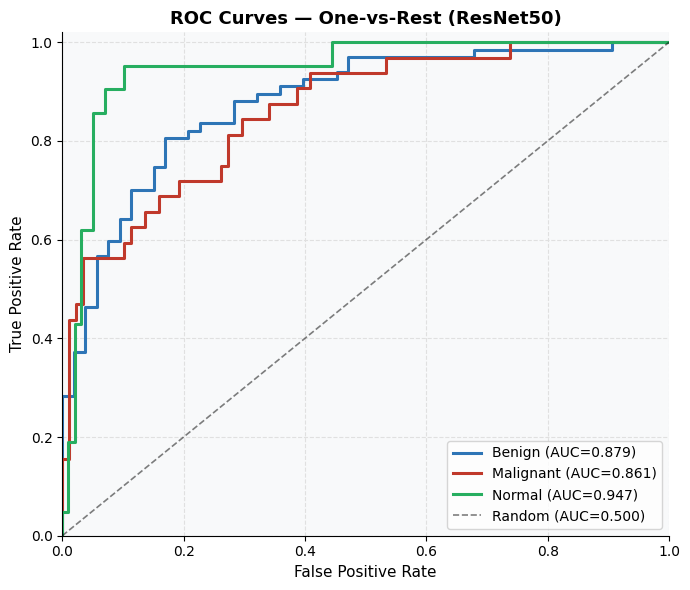

In [14]:
# step-11: per-class metrics and ROC curves
# per-class metrics bar chart
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=list(range(NUM_CLASSES)))
x = np.arange(NUM_CLASSES); w = 0.25

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.set_facecolor('#F8F9FA'); ax.grid(True, color='#E0E0E0', linewidth=0.8, linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
b1 = ax.bar(x-w, p*100, w, label='Precision', color='#2E75B6', alpha=0.88)
b2 = ax.bar(x,   r*100, w, label='Recall',    color='#27AE60', alpha=0.88)
b3 = ax.bar(x+w, f1*100,w, label='F1 Score',  color='#E67E22', alpha=0.88)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.8, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.set_ylabel('Score (%)', fontsize=11); ax.set_ylim(0, 112)
ax.set_title('Per-Class Precision, Recall & F1 — Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curves
y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
colors = ['#2E75B6', '#C0392B', '#27AE60']
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_facecolor('#F8F9FA'); ax.grid(True, color='#E0E0E0', linewidth=0.8, linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_prob[:, i])
    ra = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=2.2, label=f'{cls} (AUC={ra:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1.2,alpha=0.5,label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=11); ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — One-vs-Rest (ResNet50)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right'); ax.set_xlim(0,1); ax.set_ylim(0,1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:

model.save(f'{OUTPUT_DIR}/busi_resnet50_final.keras')
print('Model saved.')

from sklearn.metrics import f1_score
macro_f1 = f1_score(y_true, y_pred, average='macro')

results = {
    'total_images':   split_info['total_images'],
    'total_patients': split_info['total_patients'],
    'train_images':   split_info['train_images'],
    'train_patients': split_info['train_patients'],
    'val_images':     split_info['val_images'],
    'val_patients':   split_info['val_patients'],
    'test_images':    split_info['test_images'],
    'test_patients':  split_info['test_patients'],
    'test_accuracy':  float(accuracy_score(y_true, y_pred)),
    'macro_f1':       float(macro_f1),
}
import json
with open(f'{OUTPUT_DIR}/results.json','w') as fp:
    json.dump(results, fp, indent=2)

print('\n final results summary ')
for k,v in results.items(): print(f'  {k}: {v}')

import shutil
shutil.make_archive('/content/busi_outputs', 'zip', OUTPUT_DIR)
print('\nOutputs zipped to /content/busi_outputs.zip')

from google.colab import files
files.download('/content/busi_outputs.zip')


Model saved.

 final results summary 
  total_images: 780
  total_patients: 780
  train_images: 545
  train_patients: 545
  val_images: 115
  val_patients: 115
  test_images: 120
  test_patients: 120
  test_accuracy: 0.7583333333333333
  macro_f1: 0.7404304492272136

Outputs zipped to /content/busi_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>